In [184]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report


seq_len = 30*4
overlap = 0.5
stride = int(seq_len * (1 - overlap))


# データ読み込み関数
def load_session(user="U0101", session="S0100", base_dir="../openpack_subset"):
    def load_atr(sensor):
        path = f"{base_dir}/{user}/atr/{sensor}/{session}.csv"
        df = pd.read_csv(path)
        df["datetime"] = pd.to_datetime(df["unixtime"], unit="ms", utc=True).dt.tz_convert("Asia/Tokyo")
        return df

    # --- センサデータ ---
    df_r = load_atr("atr01")  # 右手
    df_l = load_atr("atr02")  # 左手

    # --- ラベルデータ（operation / action 両方）---
    op_dir = f"{base_dir}/{user}/annotation"
    df_op_lv1 = pd.read_csv(f"{op_dir}/openpack-operations/{session}.csv")  # Lv1
    df_op_lv2 = pd.read_csv(f"{op_dir}/openpack-actions/{session}.csv")     # Lv2

    for df in [df_op_lv1, df_op_lv2]:
        df["start"] = pd.to_datetime(df["start"], format="mixed").dt.tz_convert("Asia/Tokyo")
        df["end"]   = pd.to_datetime(df["end"], format="mixed").dt.tz_convert("Asia/Tokyo")

    return df_r, df_l, df_op_lv1, df_op_lv2





# ウィンドウ分割
def window_split(df_r, df_l, df_op_lv1, df_op_lv2, window_size=256, stride=128):
    df_r = df_r.sort_values("unixtime")
    df_l = df_l.sort_values("unixtime")

    # df = pd.merge_asof(
    #     df_r, df_l,
    #     on="unixtime",
    #     suffixes=("_r", "_l"),
    #     tolerance=20,
    #     direction="nearest"
    # )

    # arr = df[[
    #     #"acc_x_r","acc_y_r","acc_z_r","gyro_x_r","gyro_y_r","gyro_z_r",
    #      "acc_x_l","acc_y_l","acc_z_l","gyro_x_l","gyro_y_l","gyro_z_l"
    # ]].values
    arr = df_l[["acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z"]].values

    unixtime = df_l["unixtime"].values

    windows, labels_lv1, labels_lv2 = [], [], []

    for start in range(0, len(arr) - window_size, stride):
        end = start + window_size
        win = arr[start:end].T
        t_ts = pd.to_datetime(unixtime[start + window_size//2], unit="ms", utc=True).tz_convert("Asia/Tokyo")

        # --- Lv1: Operation ---
        op1 = df_op_lv1[(df_op_lv1["start"] <= t_ts) & (t_ts <= df_op_lv1["end"])]
        label_lv1 = op1["operation"].values[0] if len(op1) > 0 else "None"

        # --- Lv2: Action ---
        op2 = df_op_lv2[(df_op_lv2["start"] <= t_ts) & (t_ts <= df_op_lv2["end"])]
        label_lv2 = op2["action"].values[0] if len(op2) > 0 else "None"

        windows.append(win)
        labels_lv1.append(label_lv1)
        labels_lv2.append(label_lv2)

    return np.array(windows), np.array(labels_lv1), np.array(labels_lv2)



# Dataset 定義
class IMUDataset(Dataset):
    def __init__(self, X, y, yy):

        # accelerometer: m/s^2 → g
        # gyroscope: degrees → radians 
        X = X.copy()
        X[:, 0:3, :] /= 9.80665
        X[:, 3:6, :] *= np.pi / 180.0
        
        self.X = torch.tensor(X, dtype=torch.float32) # (B, 12, 256)
        self.y = torch.tensor(y, dtype=torch.long)
        self.yy = torch.tensor(yy, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i], self.yy[i]



In [ ]:
from torch.utils.data import random_split
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    pretrain: bool            # SimCLR pretrain
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str           # directory to save results
    seed: int = 0             # random seed

valid_ops = [
    "Picking",
    "Relocate Item Label",
    "Assemble Box",
    "Insert Items",
    "Close Box",
    "Attach Box Label",
    "Scan Label",
    "Attach Shipping Label",
    "Put on Back Table",
    "Fill out Order"
]

def build_loaders_for_subject(test_user, users, sessions,
                              window_size=30*4*10,
                              stride_train=30*4*2,
                              stride_test=30*4*1,
                              valid_ratio=0.1,
                              batch_size=32,
                              config: ExperimentConfig = None):
    
    if config.model_type == "cnn-linear":
        window_size = 120 * 1
        train_stride = 60 * 1
        test_stride = 120 * 1
    elif config.model_type == "multi-trans":
        window_size = 120 * 10
        train_stride = 120 * 1
        test_stride = 120 * 1
    elif config.model_type == "dcl": #change stride 4->1
        window_size = 120 * 10
        train_stride = 120 * 1 
        test_stride = 120 * 1
    elif config.model_type == "dct":
        window_size = 120 * 10
        train_stride = 120 * 1
        test_stride = 120 * 1

    X_train, y_train, yy_train = [], [], []
    X_test,  y_test,  yy_test  = [], [], []
    test_sessions_data = {}


    # --- ユーザごとに読み込む ---
    for user in users:
        for sess in sessions:
            try:
                df_r, df_l, df_op, df_act = load_session(user, sess)
            except FileNotFoundError:
                print(f"File not found: user={user}, session={sess}")
                continue

            # テストユーザ
            if user == test_user:
                X, y, yy = window_split(df_r, df_l, df_op,df_act,
                                    window_size=window_size,
                                    stride=test_stride)
                valid = np.isin(y, valid_ops)
                X_test.append(X[valid])
                y_test.append(y[valid])
                yy_test.append(yy[valid])
                test_sessions_data[sess] = (X[valid], y[valid], yy[valid])

            # 学習ユーザ
            else:
                X, y, yy = window_split(df_r, df_l, df_op,df_act,
                                    window_size=window_size,
                                    stride=train_stride)
                valid = np.isin(y, valid_ops)
                X_train.append(X[valid])
                y_train.append(y[valid])
                yy_train.append(yy[valid])

    # --- 結合 ---
    X_train = np.concatenate(X_train)
    y_train = np.concatenate(y_train)
    yy_train = np.concatenate(yy_train)
    X_test  = np.concatenate(X_test)
    y_test  = np.concatenate(y_test)
    yy_test = np.concatenate(yy_test)

    # label encoding
    le_y = LabelEncoder()
    le_y.fit(np.unique(np.concatenate([y_train, y_test])))
    y_train_enc = le_y.transform(y_train)
    y_test_enc  = le_y.transform(y_test)

    le_yy = LabelEncoder()
    le_yy.fit(np.unique(np.concatenate([yy_train, yy_test])))
    yy_train_enc = le_yy.transform(yy_train)
    yy_test_enc  = le_yy.transform(yy_test) 

    # --- Dataset ---
    train_dataset = IMUDataset(X_train, y_train_enc, yy_train_enc)
    test_dataset  = IMUDataset(X_test,  y_test_enc, yy_test_enc)
    # --- train/valid split ---
    train_len = int(len(train_dataset) * (1 - valid_ratio))
    valid_len = len(train_dataset) - train_len
    train_ds, valid_ds = random_split(
        train_dataset,
        [train_len, valid_len],
        generator=torch.Generator().manual_seed(config.seed)
    )

    # --- DataLoader ---
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
    #test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    test_loaders = {
    sess: DataLoader(IMUDataset(d[0], le_y.transform(d[1]), le_yy.transform(d[2])),
                     batch_size=batch_size, shuffle=False)
    for sess, d in test_sessions_data.items()
    }


    print(f"[test_user={test_user}] Train={len(train_ds)}, Valid={len(valid_ds)}, Test={len(test_dataset)}")
    print(f"  Classes: {le_y.classes_}")

    return train_loader, valid_loader, test_loaders


[test_user=U0101] Train=162, Valid=19, Test=521
  Classes: ['Assemble Box' 'Attach Box Label' 'Attach Shipping Label' 'Close Box'
 'Fill out Order' 'Insert Items' 'Picking' 'Put on Back Table'
 'Relocate Item Label' 'Scan Label']
X_batch shape: torch.Size([32, 6, 1200])
y_batch shape: torch.Size([32])
yy_batch shape: torch.Size([32])


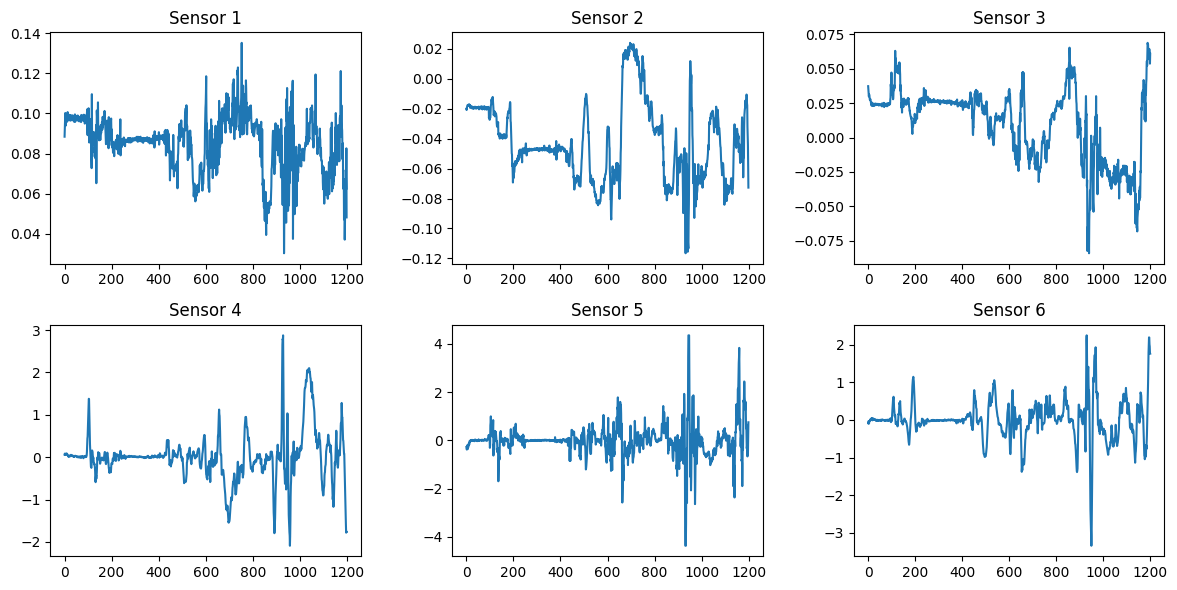

In [186]:
#check batch sample
train_loader, valid_loader, test_loaders = build_loaders_for_subject(
    test_user="U0101",
    users=["U0101","U0102"],
    sessions=["S0100"],
    config=ExperimentConfig(
        model_type="multi-trans",
        pretrain=False,
        frozen=False,
        lr_type="uniform",
        base_dir="",
        save_dir="",
        seed=0  
    ))

for X_batch, y_batch, yy_batch in train_loader:
    print("X_batch shape:", X_batch.shape)  # (B, 12, 256)
    print("y_batch shape:", y_batch.shape)  # (B,)
    print("yy_batch shape:", yy_batch.shape)  # (B,)
    break

#visualize a sample X_batch[0]
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.plot(X_batch[0, i, :].numpy())
    plt.title(f"Sensor {i+1}")
plt.tight_layout()  
plt.show()


In [187]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
import os
import json


device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

def compute_class_weights(train_loader, num_classes):
    counts = torch.zeros(num_classes)

    for _, labels, _ in train_loader:
        for c in range(num_classes):
            counts[c] += (labels == c).sum()

    total = counts.sum()
    counts[counts == 0] = 1  # 0割回避
    weights = total / (num_classes * counts)
    
    return weights                                                                                                                                                                                                                                                                               


# Train one epoch
def train_one_epoch(classifier, loader, optimizer, criterion):
    classifier.train()
    total_loss = 0
    total_n = 0

    for signals, labels, _ in loader:
        signals = signals.to(device)
        labels  = labels.to(device)

        logits, _, _ = classifier(signals)
        
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        total_n    += len(labels)

    return total_loss / total_n



# Evaluate
def evaluate(classifier, loader, criterion=None):
    classifier.eval()
    total_loss = 0
    total_n = 0

    Y, P = [], []

    with torch.no_grad():
        for signals, labels, _ in loader:
            signals = signals.to(device)
            labels  = labels.to(device)

            logits, _ , _ = classifier(signals)
            preds  = logits.argmax(dim=1)

            Y.extend(labels.cpu().numpy())
            P.extend(preds.cpu().numpy())

            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * len(labels)
                total_n    += len(labels)

    if criterion is None:
        return Y, P, None
    else:
        return Y, P, total_loss / total_n

def record_results(test_user, y_true, y_pred,
                           results_dir="results_loso"):
    os.makedirs(results_dir, exist_ok=True)
    save_path = os.path.join(results_dir, f"{test_user}.json")

    result = {
        "user": test_user,
        "y_true": list(map(int, y_true)),
        "y_pred": list(map(int, y_pred))
    }
    with open(save_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"Saved: {save_path}")


In [188]:
import importlib
import models
importlib.reload(models)
from models import SimCLR, CNN_Encoder, TaskClassifier_DCT, TaskClassifier_Transformer, TaskClassifier_LSTM, TaskClassifier_Linear, TaskClassifier_DCL
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    pretrain: bool            # SimCLR pretrain
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str             # directory to save results
    seed: int = 0             # random seed

def build_model(config: ExperimentConfig,test_user):
    """
    config.model_type : "cnn-linear" or "multi-trans"
    config.pretrain   : True/False
    config.frozen     : True/False
    """

    # --- 1. Encoder 作成 ---
    if config.pretrain:
        sim = SimCLR(input_dim=6,seq_len=120,hidden_dim=64,feature_dim=128,projection_dim=64,dropout=0.3)
        sim.load_state_dict(torch.load(
            #"/home/kisho_ucl/kisho_ws/har_warehouse/model/encoder_100_120w_1112.pth",
            #f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_leave_{test_user}_100.pth",
            f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_leave_all_S100v2_100.pth", #共通
            map_location="cpu"
        ))
        encoder = sim.encoder
        print(f"Loaded pretrained encoder leaving out user {test_user}")
    else:
        encoder = CNN_Encoder(input_dim=6, seq_len=120, hidden_dim=64, feature_dim=128, dropout=0.3)
        print("Created new encoder.")

    # --- Freeze設定 ---
    if config.frozen:
        for p in encoder.parameters():
            p.requires_grad = False

        print("Encoder is frozen.")
    else:
        print("Encoder is trainable.")

    # --- 2. Model selection ---
    if config.model_type == "cnn-linear":
        model = TaskClassifier_Linear(   # ← linear head なら別クラスでもOK
            encoder=encoder,
            feature_dim=128,
            hidden_dim=64,
            num_classes=10,
            dropout=0.1,
            freeze_encoder=config.frozen
        )
        return model

    elif config.model_type == "multi-trans":
        model = TaskClassifier_Transformer(
            encoder=encoder,
            feature_dim=128,
            window_len=120,
            overlap=0.5,
            num_heads=4,
            num_layers=3,
            num_classes=10,
            freeze_encoder=config.frozen
        )
        return model
    elif config.model_type == "dcl":
        model = TaskClassifier_DCL(
            input_dim=6,
            hidden_dim=64,
            feature_dim=128,
            lstm_hidden=128,
            num_layers=2,
            num_classes=10,
            dropout=0.1,
        )
        return model
    
    elif config.model_type == "dct":
        model = TaskClassifier_DCT(
            input_dim=6,
            hidden_dim=64,
            feature_dim=128,
            num_heads=4,
            num_layers=3,
            num_classes=10,
            dropout=0.1,
        )
        return model

    else:
        raise ValueError(f"Unknown model_type: {config.model_type}")
    
def build_optimizer(model, config: ExperimentConfig):

    # =============================
    # 1. encoder を固定する場合
    # ============================= 
    # change lr to 1e-3
    if config.frozen:
        print("Optimizer: frozen encoder → uniform LR 1e-4")
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.Adam(params, lr=1e-3)


    # =============================
    # 2. uniform LR
    # =============================
    if config.lr_type == "uniform":
        print("Optimizer: uniform lr=1e-4")
        return torch.optim.Adam(model.parameters(), lr=1e-3)


    # =============================
    # 3. layer-wise LR
    # =============================
    elif config.lr_type == "layerwise":

        encoder_lr = 1e-4
        head_lr = 1e-3

        if isinstance(model, TaskClassifier_Transformer):
            print("Optimizer: layerwise (Transformer)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.transformer.parameters(),  "lr": head_lr}, #out weight decay
                {"params": model.classifier.parameters(),   "lr": head_lr},
            ])

        elif isinstance(model, TaskClassifier_LSTM):
            print("Optimizer: layerwise (LSTM)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.lstm.parameters(),         "lr": head_lr}, # out weight decay
                {"params": model.classifier.parameters(),   "lr": head_lr},
            ])
        elif isinstance(model, TaskClassifier_Linear):
            print("Optimizer: layerwise (Linear)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.classifier.parameters(),   "lr": head_lr}, # out weight decay
            ])
        else:
            raise ValueError("Unknown model architecture for layerwise LR")

    else:
        raise ValueError(f"Unknown lr_type {config.lr_type}")




In [189]:
from copy import deepcopy
import os
import json


class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False
        self.best_state = None
        self.best_epoch = 0

    def __call__(self, epoch, val_loss, model):
        # 初回、または改善したとき
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.best_state = deepcopy(model.state_dict())
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True



In [190]:
import models
importlib.reload(models)
from models import SimCLR, CNN_Encoder, TaskClassifier_Transformer, TaskClassifier_LSTM, TaskClassifier_DCT
from dataclasses import dataclass
import random

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    pretrain: bool            # SimCLR pretrain
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str           # directory to save results
    seed: int = 0             # random seed

# Reset random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# LOSO
def run_loso_one(
        train_loader, valid_loader, test_loader,
        weight_tensor, test_user="UNKNOWN",
        max_epochs=30, patience=5,
        config: ExperimentConfig = None):

    # Set random seed
    set_seed(config.seed)

    # モデル構築
    classifier = build_model(config,test_user=test_user).to(device)
    optimizer = build_optimizer(classifier, config)

    weight_tensor = weight_tensor.to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    num_classes = 10

    # Early stopping
    early_stopper = EarlyStopping(patience=patience)

    # Training loop
    for epoch in range(1, max_epochs + 1):

        train_loss = train_one_epoch(classifier, train_loader, optimizer, criterion)
        _, _, valid_loss = evaluate(classifier, valid_loader, criterion)
        Y_tmp, P_tmp, test_loss = evaluate(classifier, test_loader, criterion)
        f1_tmp = f1_score(Y_tmp, P_tmp, average="macro")

        print(
            f"[Epoch {epoch}/{max_epochs}] "
            f"Train={train_loss:.4f} | "
            f"Valid={valid_loss:.4f} | "
            f"Test={test_loss:.4f} | F1={f1_tmp:.4f}"
        )

        # early stopping check
        early_stopper(epoch, valid_loss, classifier)
        if early_stopper.early_stop:
            print("Early stopping.")
            break

    # Load best model
    classifier.load_state_dict(early_stopper.best_state)

    Y, P, _ = evaluate(classifier, test_loader, criterion)
    final_f1 = f1_score(Y, P, average="macro")

    print(f"[SAVE PATH] {config.save_dir}/{test_user}.json")


    print(f"[{test_user}] Final F1 = {final_f1:.4f} | BestEpoch={early_stopper.best_epoch}")

    record_results(test_user, Y, P, results_dir=config.save_dir)

    return final_f1, Y, P, classifier

In [205]:
# ==========================================
# 実験設定
# ==========================================

configs = [
    # ────────────── No Pretrain ──────────────
    #ExperimentConfig("multi-trans", False, False, "uniform",   "T1_noPT_uniform", ""),
    #ExperimentConfig("multi-trans", False, False, "layerwise", "T2_noPT_layerwise", ""),

    # ────────────── Pretrain + Frozen ──────────────
    ExperimentConfig("multi-trans", True,  True,  "none",      "T3_PT_frozen", ""), 
    # ────────────── Pretrain + Fine-tune ──────────────
    #ExperimentConfig("multi-trans", True,  False, "uniform",   "T4_PT_ft_uniform", ""),
    #ExperimentConfig("multi-trans", True,  False, "layerwise", "T5_PT_ft_layerwise", ""),

    # ────────────── No Pretrain ──────────────
    #ExperimentConfig("cnn-linear", False, False, "uniform",   "T6_noPT_uniform", ""),
    #ExperimentConfig("cnn-linear", False, False, "layerwise", "T7_noPT_layerwise", ""),
    # ────────────── Pretrain + Frozen ──────────────
    #ExperimentConfig("cnn-linear", True,  True,  "none",      "T8_PT_frozen", ""),
    # ────────────── Pretrain + Fine-tune ──────────────
    #ExperimentConfig("cnn-linear", True,  False, "uniform",   "T9_PT_ft_uniform", ""),
    #ExperimentConfig("cnn-linear", True,  False, "layerwise", "T10_PT_ft_layerwise", ""),

    #ExperimentConfig("dcl", True,  False, "uniform", "T11_noPT_uniform", ""),
    #ExperimentConfig("dct", True,  False, "uniform", "T12_noPT_uniform", ""),
]


seeds = [0]

users = ["U0101", "U0102", "U0103", "U0104", "U0105",
         "U0106", "U0107", "U0108", "U0109", "U0110",
         "U0111", "U0201", "U0206", "U0207", "U0208",
         "U0209"
         ]


#users = ["U0101","U0102"]
#sessions = ["S0100","S0200","S0300","S0400","S0500"]
sessions = ["S0100"]

num_classes = 10  # ← Operation Recognition 用


# ==========================================
# 実験ループ（SEED → CONFIG → LOSO）
# ==========================================
for seed in seeds:

    print(f"\n=========== SEED {seed} ===========")

    for cfg in configs[:]:

        print("===================================")
        print(f" Variant: {cfg.base_dir}")
        print("===================================")

        # seed ＆ save_dir の設定
        cfg.seed = seed
        #cfg.save_dir = f"results_loso/seed{seed}/{cfg.base_dir}"

        # --- LOSO: test_user を 1 名ずつ抜く ---
        for test_user in users:

            set_seed(seed)

            # ---- Loader 構築----
            train_loader, valid_loader, test_loaders = build_loaders_for_subject(
                test_user=test_user,
                users=users,
                sessions=sessions,
                window_size=30*4*10,
                stride_train=30*4*2,
                stride_test=30*4*1,
                valid_ratio=0.1,
                batch_size=32,
                config=cfg
            )

            # ---- class weight----
            weight_tensor = compute_class_weights(train_loader, num_classes=num_classes)
            weight_tensor = weight_tensor.to(device)

            # ---- 1 被験者に対する LOSO 学習----
            for sess, loader in test_loaders.items():
                save_dir_sess = f"results_loso/seed{seed}/{cfg.base_dir}/{sess}"
                cfg.save_dir = save_dir_sess
                os.makedirs(save_dir_sess, exist_ok=True)

                f1, Y, P, classifier = run_loso_one(
                    train_loader,
                    valid_loader,
                    loader,
                    weight_tensor=weight_tensor,
                    test_user=test_user,
                    max_epochs=30,
                    patience=5,
                    config=cfg,
                )

            print(f"  Seed={seed}, User={test_user}, F1={f1:.4f}")



=========== SEED 0 ===========
 Variant: T3_PT_frozen
[test_user=U0101] Train=1994, Valid=222, Test=521
  Classes: ['Assemble Box' 'Attach Box Label' 'Attach Shipping Label' 'Close Box'
 'Fill out Order' 'Insert Items' 'Picking' 'Put on Back Table'
 'Relocate Item Label' 'Scan Label']
Loaded pretrained encoder leaving out user U0101
Encoder is frozen.
Optimizer: frozen encoder → uniform LR 1e-4
[Epoch 1/30] Train=2.0617 | Valid=1.6271 | Test=1.5302 | F1=0.3154
[Epoch 2/30] Train=1.3615 | Valid=0.8936 | Test=0.8690 | F1=0.6221
[Epoch 3/30] Train=0.7870 | Valid=0.5911 | Test=0.5376 | F1=0.7645
[Epoch 4/30] Train=0.6601 | Valid=0.4546 | Test=0.4285 | F1=0.8028
[Epoch 5/30] Train=0.5624 | Valid=0.6064 | Test=0.4894 | F1=0.7868
[Epoch 6/30] Train=0.5724 | Valid=0.5608 | Test=0.4391 | F1=0.8160
[Epoch 7/30] Train=0.4602 | Valid=0.3464 | Test=0.3515 | F1=0.8390
[Epoch 8/30] Train=0.4232 | Valid=0.4950 | Test=0.4854 | F1=0.8366
[Epoch 9/30] Train=0.3710 | Valid=0.5173 | Test=0.4908 | F1=0.816

[INFO] Loading: results_loso/1212_3/seed0


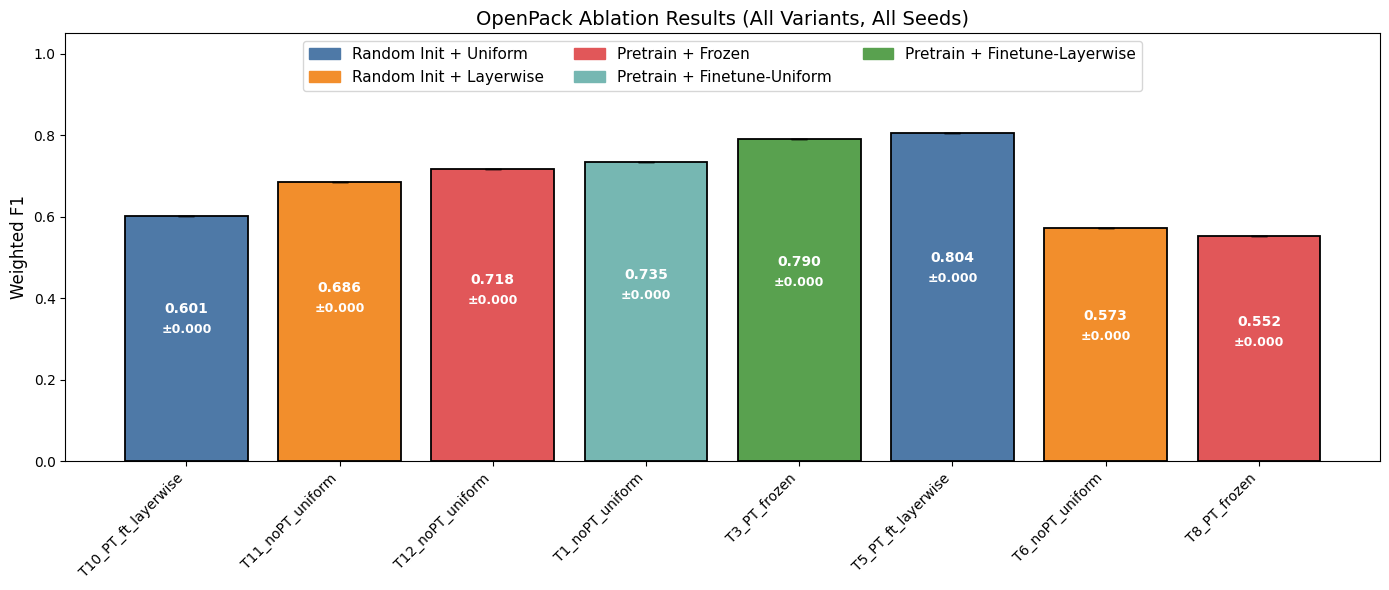

In [210]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. seed 全体に対応した variant × session の F1 読み込み
# =========================================================
def load_variant_scores_new(
    root="results_loso",
    target_session="S0100",
    target_seed=None    # ← ★ None にすると seed0~seedN をすべて読む
):
    """
    return:
        { variant: [f1_seed0, f1_seed1, ..., f1_seedN] }
    """

    scores = {}

    # ---- seed ディレクトリ ----
    for seed in sorted(os.listdir(root)):
        if target_seed is not None and seed != target_seed:
            continue

        seed_dir = os.path.join(root, seed)
        if not os.path.isdir(seed_dir):
            continue

        print(f"[INFO] Loading: {seed_dir}")

        # ---- variant ----
        for variant in sorted(os.listdir(seed_dir)):
            var_dir = os.path.join(seed_dir, variant)
            if not os.path.isdir(var_dir):
                continue

            if variant not in scores:
                scores[variant] = []

            sess_dir = os.path.join(var_dir, target_session)
            if not os.path.isdir(sess_dir):
                scores[variant].append(None)
                continue

            # ---- session 内の JSON（被験者ごと） ----
            per_subject_f1 = []

            for fname in sorted(os.listdir(sess_dir)):
                if not fname.endswith(".json"):
                    continue

                json_path = os.path.join(sess_dir, fname)
                with open(json_path, "r") as fp:
                    r = json.load(fp)

                y = np.array(r["y_true"])
                p = np.array(r["y_pred"])

                f1 = f1_score(y, p, average="macro")
                per_subject_f1.append(f1)

            if len(per_subject_f1) == 0:
                scores[variant].append(None)
            else:
                scores[variant].append(float(np.mean(per_subject_f1)))

    return scores


# =========================================================
# 2. seed 平均・標準偏差
# =========================================================
def summarize_scores(scores):
    summary = {}
    for variant, vals in scores.items():
        vs = [v for v in vals if v is not None]
        summary[variant] = {
            "mean_f1": np.nanmean(vs),
            "std_f1":  np.nanstd(vs),
            "num_seeds": len(vs)
        }
    return summary


# ======= 実行: seed 全体を読み込む =======
scores = load_variant_scores_new(
    root="results_loso/1212_3",
    target_session="S0100",
    target_seed="seed0"      # ★ 全 seed
)

summary = summarize_scores(scores)

df = pd.DataFrame(
    [(k, v["mean_f1"], v["std_f1"], v["num_seeds"]) for k, v in summary.items()],
    columns=["variant", "mean_f1", "std_f1", "num_seeds"]
)

# =========================================================
# Plot：全 variant をそのまま並べる
# =========================================================

variants = df["variant"].tolist()
means    = df["mean_f1"].to_numpy()
stds     = df["std_f1"].to_numpy()

# バー位置
x = np.arange(len(variants))

# 5色ローテーション
bar_colors = [colors5[i % 5] for i in range(len(variants))]

plt.figure(figsize=(14, 6))

plt.bar(
    x, means, yerr=stds,
    color=bar_colors,
    capsize=6,
    edgecolor="black",
    linewidth=1.3
)

# バー内部テキスト
for xi, m, s in zip(x, means, stds):
    plt.text(xi, m*0.62, f"{m:.3f}",
             ha="center", va="center",
             fontsize=10, fontweight="bold", color="white")
    plt.text(xi, m*0.62 - 0.05, f"±{s:.3f}",
             ha="center", va="center",
             fontsize=9, fontweight="bold", color="white")

# x 軸ラベル（variant 名）
plt.xticks(x, variants, rotation=45, ha="right", fontsize=10)

plt.ylabel("Weighted F1", fontsize=12)
plt.ylim(0, 1.05)

# 凡例（学習戦略）
handles = [plt.Rectangle((0,0),1,1,color=c) for c in colors5]
plt.legend(handles, labels5, ncol=3, fontsize=11, loc="upper center")

plt.title("OpenPack Ablation Results (All Variants, All Seeds)", fontsize=14)
plt.tight_layout()
plt.show()


In [193]:
summary

{'T1_noPT_uniform': {'mean_f1': np.float64(0.735269715062091),
  'std_f1': np.float64(0.0),
  'num_seeds': 1}}

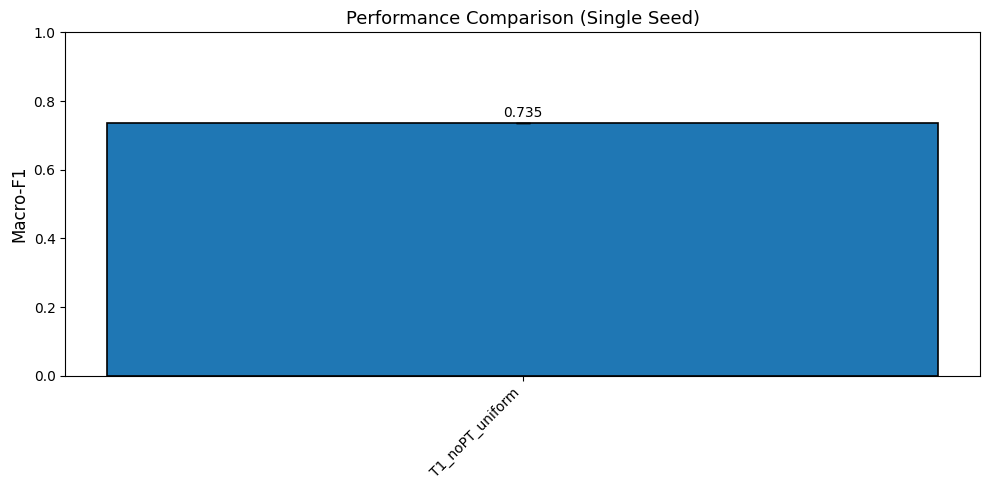

In [194]:
import matplotlib.pyplot as plt
import numpy as np

# summary dict を展開
variants = list(summary.keys())
means = [summary[v]["mean_f1"] for v in variants]
stds  = [summary[v]["std_f1"] for v in variants]

x = np.arange(len(variants))

plt.figure(figsize=(10, 5))
plt.bar(
    x, means, yerr=stds,
    capsize=5,
    edgecolor="black",
    linewidth=1.2
)

# bar 上に数値表示
for xi, m in zip(x, means):
    plt.text(
        xi, m + 0.01,
        f"{m:.3f}",
        ha="center", va="bottom", fontsize=10
    )

plt.xticks(x, variants, rotation=45, ha="right")
plt.ylabel("Macro-F1", fontsize=12)
plt.ylim(0, 1.0)
plt.title("Performance Comparison (Single Seed)", fontsize=13)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2447983/2603322913.py:82: RuntimeWarning: Mean of empty slice
  "mean_f1": np.nanmean(vs),
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


[INFO] Loading: results_loso/1205
[INFO] Loading: results_loso/1210
[INFO] Loading: results_loso/1212
[INFO] Loading: results_loso/1212_2
[INFO] Loading: results_loso/1212_3
[INFO] Loading: results_loso/seed0
| Variant | Mean(F1) | Std(F1) | #Seeds |
|---|---|---|---|
| seed0 | nan | nan | 0 |
| seed1 | nan | nan | 0 |
| seed2 | nan | nan | 0 |
| seed3 | nan | nan | 0 |
| seed4 | nan | nan | 0 |
| T1_noPT_uniform | 0.735 | 0.000 | 1 |



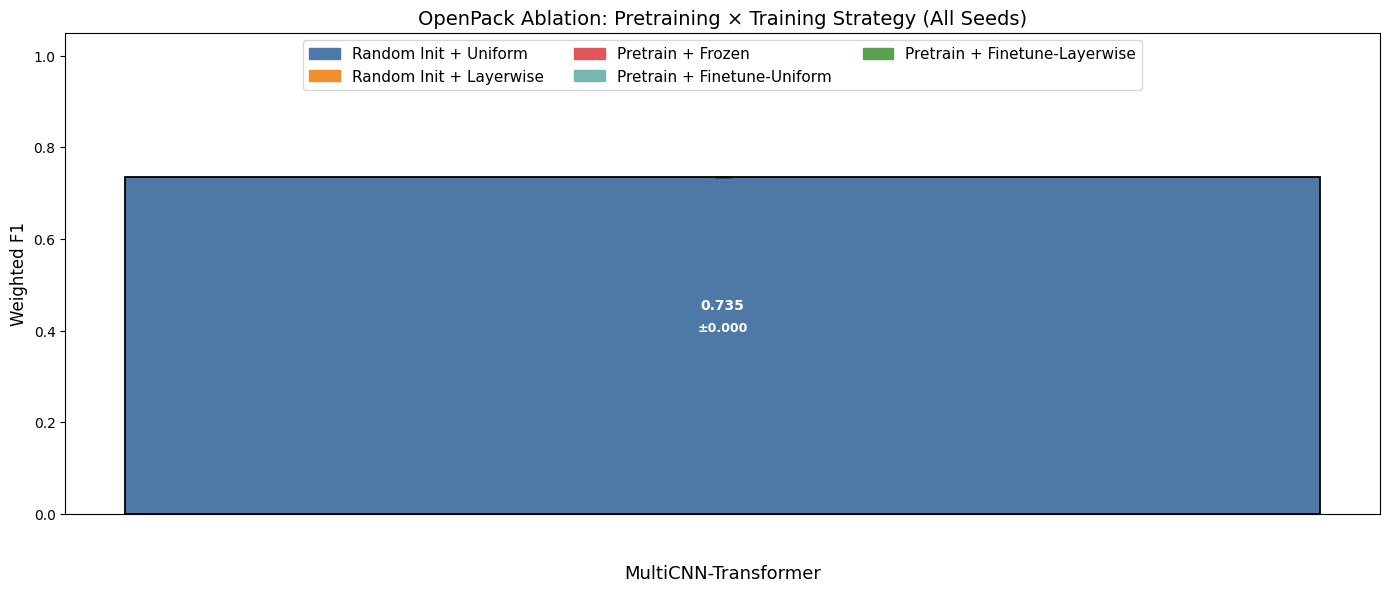

In [195]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. seed 全体に対応した variant × session の F1 読み込み
# =========================================================
def load_variant_scores_new(
    root="results_loso",
    target_session="S0100",
    target_seed=None    # ← ★ None にすると seed0~seedN をすべて読む
):
    """
    return:
        { variant: [f1_seed0, f1_seed1, ..., f1_seedN] }
    """

    scores = {}

    # ---- seed ディレクトリ ----
    for seed in sorted(os.listdir(root)):
        if target_seed is not None and seed != target_seed:
            continue

        seed_dir = os.path.join(root, seed)
        if not os.path.isdir(seed_dir):
            continue

        print(f"[INFO] Loading: {seed_dir}")

        # ---- variant ----
        for variant in sorted(os.listdir(seed_dir)):
            var_dir = os.path.join(seed_dir, variant)
            if not os.path.isdir(var_dir):
                continue

            if variant not in scores:
                scores[variant] = []

            sess_dir = os.path.join(var_dir, target_session)
            if not os.path.isdir(sess_dir):
                scores[variant].append(None)
                continue

            # ---- session 内の JSON（被験者ごと） ----
            per_subject_f1 = []

            for fname in sorted(os.listdir(sess_dir)):
                if not fname.endswith(".json"):
                    continue

                json_path = os.path.join(sess_dir, fname)
                with open(json_path, "r") as fp:
                    r = json.load(fp)

                y = np.array(r["y_true"])
                p = np.array(r["y_pred"])

                f1 = f1_score(y, p, average="macro")
                per_subject_f1.append(f1)

            if len(per_subject_f1) == 0:
                scores[variant].append(None)
            else:
                scores[variant].append(float(np.mean(per_subject_f1)))

    return scores


# =========================================================
# 2. seed 平均・標準偏差
# =========================================================
def summarize_scores(scores):
    summary = {}
    for variant, vals in scores.items():
        vs = [v for v in vals if v is not None]
        summary[variant] = {
            "mean_f1": np.nanmean(vs),
            "std_f1":  np.nanstd(vs),
            "num_seeds": len(vs)
        }
    return summary


# ======= 実行: seed 全体を読み込む =======
scores = load_variant_scores_new(
    root="results_loso",
    target_session="S0100",
    target_seed=None      # ★ 全 seed
)

summary = summarize_scores(scores)

df = pd.DataFrame(
    [(k, v["mean_f1"], v["std_f1"], v["num_seeds"]) for k, v in summary.items()],
    columns=["variant", "mean_f1", "std_f1", "num_seeds"]
)

# Markdown 出力（確認用）
md = "| Variant | Mean(F1) | Std(F1) | #Seeds |\n"
md += "|---|---|---|---|\n"
for _, r in df.iterrows():
    md += f"| {r.variant} | {r.mean_f1:.3f} | {r.std_f1:.3f} | {int(r.num_seeds)} |\n"
print(md)



# =========================================================
# 3. Plot 設定（グループ A/B/C・色 5 種類）
# =========================================================

# 色 5 種類
colors5 = [
    "#4e79a7",  # Random Init + Uniform
    "#f28e2c",  # Random Init + Layerwise
    "#e15759",  # Pretrain + Frozen
    "#76b7b2",  # Pretrain + Finetune-Uniform
    "#59a14f",  # Pretrain + Finetune-Layerwise
]

labels5 = [
    "Random Init + Uniform",
    "Random Init + Layerwise",
    "Pretrain + Frozen",
    "Pretrain + Finetune-Uniform",
    "Pretrain + Finetune-Layerwise",
]

# variant の所属グループ
group_A = ["T6_noPT_uniform","T7_noPT_layerwise","T8_PT_frozen","T9_PT_ft_uniform","T10_PT_ft_layerwise"]
group_B = ["T6_noPT_uniform_smooth","T7_noPT_layerwise_smooth","T8_PT_frozen_smooth","T9_PT_ft_uniform_smooth","T10_PT_ft_layerwise_smooth"]
group_C = ["T1_noPT_uniform","T2_noPT_layerwise","T3_PT_frozen","T4_PT_ft_uniform","T5_PT_ft_layerwise"]

def label_group(v):
    if v in group_A:
        return "A"
    elif v in group_B:
        return "B"
    elif v in group_C:
        return "C"
    else:
        return "Unknown"

df["group"] = df["variant"].apply(label_group)

# グループ順に並べる（A → B → C）
df_sorted = pd.concat([
    df[df["group"]=="A"],
    df[df["group"]=="B"],
    df[df["group"]=="C"]
], axis=0).reset_index(drop=True)


# =========================================================
# 4. Plot 本体：seed std がそのまま使われる
# =========================================================

variants = df_sorted["variant"].tolist()
means    = df_sorted["mean_f1"].to_numpy()
stds     = df_sorted["std_f1"].to_numpy()
groups   = df_sorted["group"].tolist()

# バー位置
x = []
gap = 2.0
pos = 0

for i in range(len(variants)):
    if i > 0 and groups[i-1] != groups[i]:
        pos += gap
    x.append(pos)
    pos += 0.9

x = np.array(x)

# 色（グループ内 index で5色をローテーション）
index_within_group = [(i % 5) for i in range(len(variants))]
bar_colors = [colors5[idx] for idx in index_within_group]

plt.figure(figsize=(14, 6))

plt.bar(
    x, means, yerr=stds,
    color=bar_colors,
    capsize=6,
    edgecolor="black",
    linewidth=1.3
)

# バー内部に mean ± std
for xi, m, s in zip(x, means, stds):
    plt.text(xi, m*0.62, f"{m:.3f}",
             ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    plt.text(xi, m*0.62 - 0.05, f"±{s:.3f}",
             ha="center", va="center", fontsize=9, fontweight="bold", color="white")

plt.xticks([], [])
plt.ylabel("Weighted F1", fontsize=12)
plt.ylim(0, 1.05)

# グループ位置
idx_A = np.where(df_sorted["group"]=="A")[0]
idx_B = np.where(df_sorted["group"]=="B")[0]
idx_C = np.where(df_sorted["group"]=="C")[0]
mid_A = np.mean(x[idx_A])
mid_B = np.mean(x[idx_B])
mid_C = np.mean(x[idx_C])

plt.text(mid_A, -0.14, "CNN-Linear", ha="center", fontsize=13)
plt.text(mid_B, -0.14, "CNN-Linear (Smoothed)", ha="center", fontsize=13)
plt.text(mid_C, -0.14, "MultiCNN-Transformer", ha="center", fontsize=13)

# 凡例
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors5]
plt.legend(handles, labels5, ncol=3, fontsize=11, loc="upper center")

plt.title("OpenPack Ablation: Pretraining × Training Strategy (All Seeds)", fontsize=14)
plt.tight_layout()
plt.show()


In [196]:
summary

{'seed0': {'mean_f1': np.float64(nan),
  'std_f1': np.float64(nan),
  'num_seeds': 0},
 'seed1': {'mean_f1': np.float64(nan),
  'std_f1': np.float64(nan),
  'num_seeds': 0},
 'seed2': {'mean_f1': np.float64(nan),
  'std_f1': np.float64(nan),
  'num_seeds': 0},
 'seed3': {'mean_f1': np.float64(nan),
  'std_f1': np.float64(nan),
  'num_seeds': 0},
 'seed4': {'mean_f1': np.float64(nan),
  'std_f1': np.float64(nan),
  'num_seeds': 0},
 'T1_noPT_uniform': {'mean_f1': np.float64(0.735269715062091),
  'std_f1': np.float64(0.0),
  'num_seeds': 1}}

[INFO] Loading: results_loso/1205
[INFO] Loading: results_loso/1210
[INFO] Loading: results_loso/1212
[INFO] Loading: results_loso/1212_2
[INFO] Loading: results_loso/1212_3
[INFO] Loading: results_loso/seed0


/tmp/ipykernel_2447983/2603322913.py:82: RuntimeWarning: Mean of empty slice
  "mean_f1": np.nanmean(vs),
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


| Variant | Mean(F1) | Std(F1) | #Seeds |
|---|---|---|---|
| seed0 | nan | nan | 0 |
| seed1 | nan | nan | 0 |
| seed2 | nan | nan | 0 |
| seed3 | nan | nan | 0 |
| seed4 | nan | nan | 0 |
| T1_noPT_uniform | 0.735 | 0.000 | 1 |



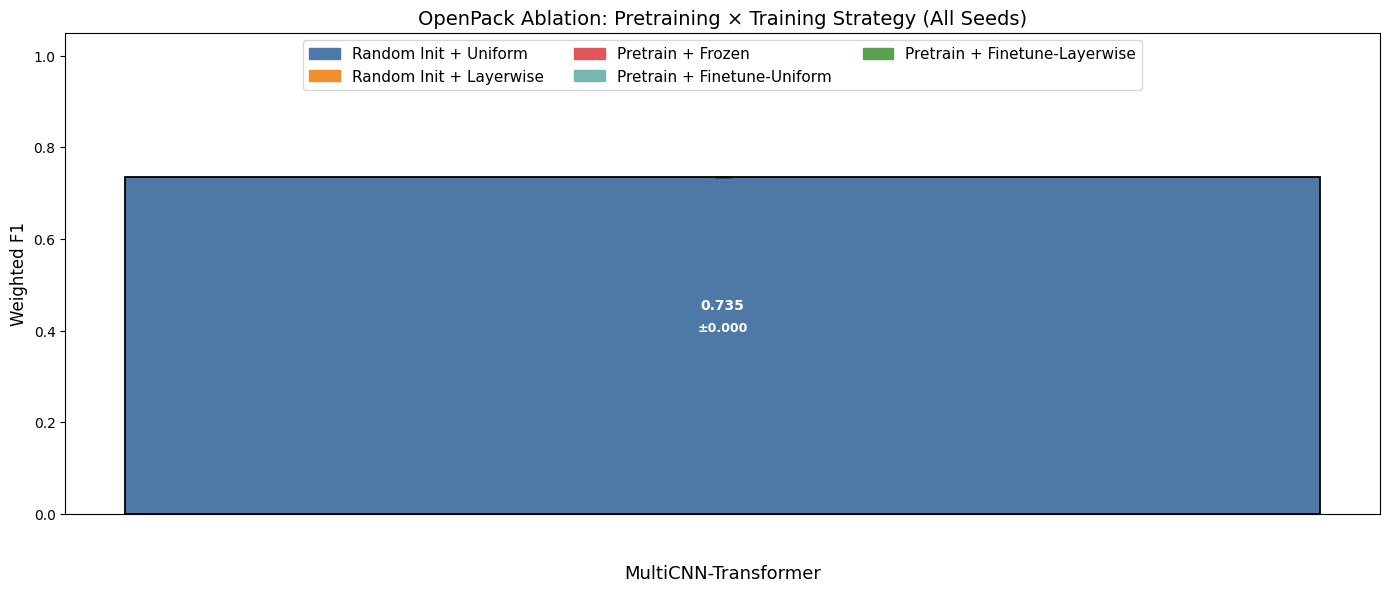

In [197]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. seed 全体に対応した variant × session の F1 読み込み
# =========================================================
def load_variant_scores_new(
    root="results_loso",
    target_session="S0100",
    target_seed=None    # ← ★ None にすると seed0~seedN をすべて読む
):
    """
    return:
        { variant: [f1_seed0, f1_seed1, ..., f1_seedN] }
    """

    scores = {}

    # ---- seed ディレクトリ ----
    for seed in sorted(os.listdir(root)):
        if target_seed is not None and seed != target_seed:
            continue

        seed_dir = os.path.join(root, seed)
        if not os.path.isdir(seed_dir):
            continue

        print(f"[INFO] Loading: {seed_dir}")

        # ---- variant ----
        for variant in sorted(os.listdir(seed_dir)):
            var_dir = os.path.join(seed_dir, variant)
            if not os.path.isdir(var_dir):
                continue

            if variant not in scores:
                scores[variant] = []

            sess_dir = os.path.join(var_dir, target_session)
            if not os.path.isdir(sess_dir):
                scores[variant].append(None)
                continue

            # ---- session 内の JSON（被験者ごと） ----
            per_subject_f1 = []

            for fname in sorted(os.listdir(sess_dir)):
                if not fname.endswith(".json"):
                    continue

                json_path = os.path.join(sess_dir, fname)
                with open(json_path, "r") as fp:
                    r = json.load(fp)

                y = np.array(r["y_true"])
                p = np.array(r["y_pred"])

                f1 = f1_score(y, p, average="macro")
                per_subject_f1.append(f1)

            if len(per_subject_f1) == 0:
                scores[variant].append(None)
            else:
                scores[variant].append(float(np.mean(per_subject_f1)))

    return scores


# =========================================================
# 2. seed 平均・標準偏差
# =========================================================
def summarize_scores(scores):
    summary = {}
    for variant, vals in scores.items():
        vs = [v for v in vals if v is not None]
        summary[variant] = {
            "mean_f1": np.nanmean(vs),
            "std_f1":  np.nanstd(vs),
            "num_seeds": len(vs)
        }
    return summary


# ======= 実行: seed 全体を読み込む =======
scores = load_variant_scores_new(
    root="results_loso",
    target_session="S0100",
    target_seed=None      # ★ 全 seed
)

summary = summarize_scores(scores)

df = pd.DataFrame(
    [(k, v["mean_f1"], v["std_f1"], v["num_seeds"]) for k, v in summary.items()],
    columns=["variant", "mean_f1", "std_f1", "num_seeds"]
)

# Markdown 出力（確認用）
md = "| Variant | Mean(F1) | Std(F1) | #Seeds |\n"
md += "|---|---|---|---|\n"
for _, r in df.iterrows():
    md += f"| {r.variant} | {r.mean_f1:.3f} | {r.std_f1:.3f} | {int(r.num_seeds)} |\n"
print(md)



# =========================================================
# 3. Plot 設定（グループ A/B/C・色 5 種類）
# =========================================================

# 色 5 種類
colors5 = [
    "#4e79a7",  # Random Init + Uniform
    "#f28e2c",  # Random Init + Layerwise
    "#e15759",  # Pretrain + Frozen
    "#76b7b2",  # Pretrain + Finetune-Uniform
    "#59a14f",  # Pretrain + Finetune-Layerwise
]

labels5 = [
    "Random Init + Uniform",
    "Random Init + Layerwise",
    "Pretrain + Frozen",
    "Pretrain + Finetune-Uniform",
    "Pretrain + Finetune-Layerwise",
]

# variant の所属グループ
group_A = ["T6_noPT_uniform","T7_noPT_layerwise","T8_PT_frozen","T9_PT_ft_uniform","T10_PT_ft_layerwise"]
group_B = ["T6_noPT_uniform_smooth","T7_noPT_layerwise_smooth","T8_PT_frozen_smooth","T9_PT_ft_uniform_smooth","T10_PT_ft_layerwise_smooth"]
group_C = ["T1_noPT_uniform","T2_noPT_layerwise","T3_PT_frozen","T4_PT_ft_uniform","T5_PT_ft_layerwise"]

def label_group(v):
    if v in group_A:
        return "A"
    elif v in group_B:
        return "B"
    elif v in group_C:
        return "C"
    else:
        return "Unknown"

df["group"] = df["variant"].apply(label_group)

# グループ順に並べる（A → B → C）
df_sorted = pd.concat([
    df[df["group"]=="A"],
    df[df["group"]=="B"],
    df[df["group"]=="C"]
], axis=0).reset_index(drop=True)


# =========================================================
# 4. Plot 本体：seed std がそのまま使われる
# =========================================================

variants = df_sorted["variant"].tolist()
means    = df_sorted["mean_f1"].to_numpy()
stds     = df_sorted["std_f1"].to_numpy()
groups   = df_sorted["group"].tolist()

# バー位置
x = []
gap = 2.0
pos = 0

for i in range(len(variants)):
    if i > 0 and groups[i-1] != groups[i]:
        pos += gap
    x.append(pos)
    pos += 0.9

x = np.array(x)

# 色（グループ内 index で5色をローテーション）
index_within_group = [(i % 5) for i in range(len(variants))]
bar_colors = [colors5[idx] for idx in index_within_group]

plt.figure(figsize=(14, 6))

plt.bar(
    x, means, yerr=stds,
    color=bar_colors,
    capsize=6,
    edgecolor="black",
    linewidth=1.3
)

# バー内部に mean ± std
for xi, m, s in zip(x, means, stds):
    plt.text(xi, m*0.62, f"{m:.3f}",
             ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    plt.text(xi, m*0.62 - 0.05, f"±{s:.3f}",
             ha="center", va="center", fontsize=9, fontweight="bold", color="white")

plt.xticks([], [])
plt.ylabel("Weighted F1", fontsize=12)
plt.ylim(0, 1.05)

# グループ位置
idx_A = np.where(df_sorted["group"]=="A")[0]
idx_B = np.where(df_sorted["group"]=="B")[0]
idx_C = np.where(df_sorted["group"]=="C")[0]
mid_A = np.mean(x[idx_A])
mid_B = np.mean(x[idx_B])
mid_C = np.mean(x[idx_C])

plt.text(mid_A, -0.14, "CNN-Linear", ha="center", fontsize=13)
plt.text(mid_B, -0.14, "CNN-Linear (Smoothed)", ha="center", fontsize=13)
plt.text(mid_C, -0.14, "MultiCNN-Transformer", ha="center", fontsize=13)

# 凡例
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors5]
plt.legend(handles, labels5, ncol=3, fontsize=11, loc="upper center")

plt.title("OpenPack Ablation: Pretraining × Training Strategy (All Seeds)", fontsize=14)
plt.tight_layout()
plt.show()


In [198]:
scores

{'seed0': [None, None, None, None, None],
 'seed1': [None],
 'seed2': [None],
 'seed3': [None],
 'seed4': [None],
 'T1_noPT_uniform': [0.735269715062091]}

/tmp/ipykernel_2447983/2636684428.py:157: RuntimeWarning: Mean of empty slice
  "mean_f1": np.nanmean(vs),
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[INFO] Loading: results_loso/1205
[INFO] Loading: results_loso/1210
[INFO] Loading: results_loso/1212
[INFO] Loading: results_loso/1212_2
[INFO] Loading: results_loso/1212_3
[INFO] Loading: results_loso/seed0
| Variant | Mean(F1) | Std(F1) | #Seeds |
|---|---|---|---|
| seed0 | nan | nan | 0 |
| seed1 | nan | nan | 0 |
| seed2 | nan | nan | 0 |
| seed3 | nan | nan | 0 |
| seed4 | nan | nan | 0 |
| T1_noPT_uniform | 0.735 | 0.000 | 1 |



/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


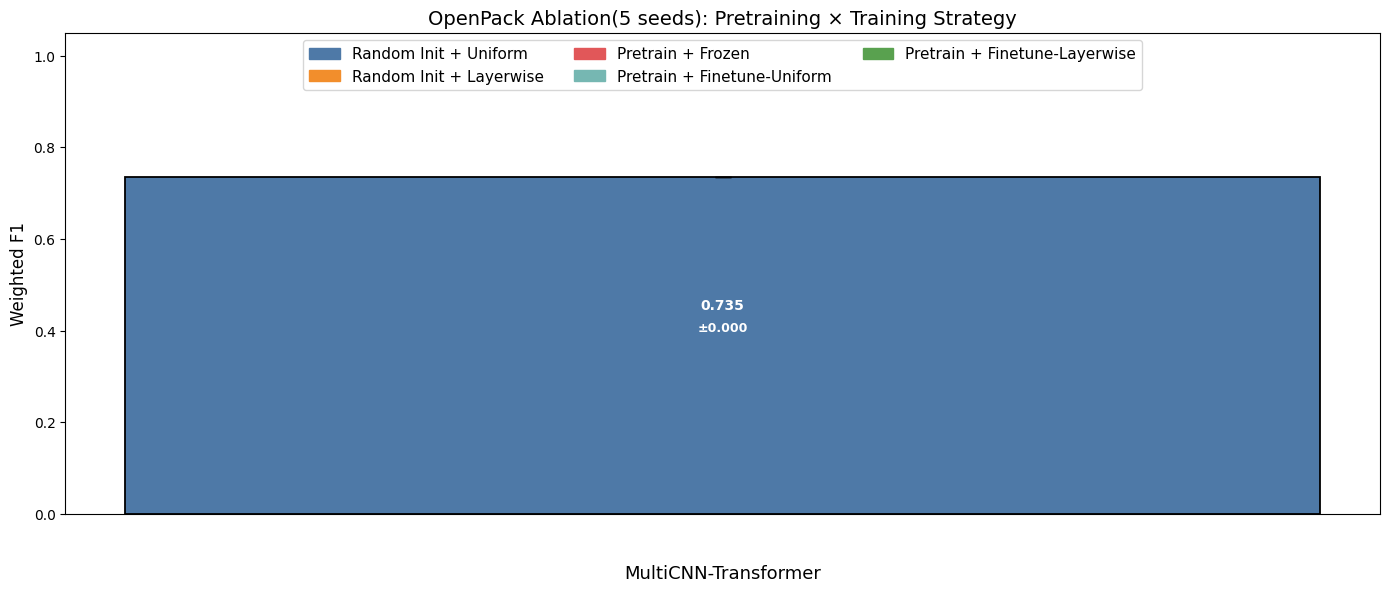

In [199]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score


# def load_variant_scores_new(
#     root="results_loso",
#     target_session="S0200",   # ← ★ 集計したい session を指定
#     #target_seed="seed0"       # ← ★ 必要なら seed も指定
#     target_seed=None
# ):
#     """
#     return:
#         { variant: [seed_mean_f1] }  # 今は session を固定するので 1 seed=1値
#     """

#     scores = {}

#     # ---- seed ディレクトリ ----
#     for seed in sorted(os.listdir(root)):
#         if target_seed is not None and seed != target_seed:
#             continue

#         seed_dir = os.path.join(root, seed)
#         if not os.path.isdir(seed_dir):
#             continue
#         print(f"[INFO] Loading: {seed_dir}")

#         # ---- variant ディレクトリ ----
#         for variant in sorted(os.listdir(seed_dir)):
#             var_dir = os.path.join(seed_dir, variant)
#             if not os.path.isdir(var_dir):
#                 continue

#             # dict init
#             if variant not in scores:
#                 scores[variant] = []

#             # ---- session ディレクトリ ----
#             sess_dir = os.path.join(var_dir, target_session)
#             if not os.path.isdir(sess_dir):
#                 print(f"  [WARN] {sess_dir} not found")
#                 scores[variant].append(None)
#                 continue

#             # ---- session 内の JSON（各被験者） ----
#             per_subject_f1 = []

#             for fname in sorted(os.listdir(sess_dir)):
#                 if not fname.endswith(".json"):
#                     continue

#                 json_path = os.path.join(sess_dir, fname)
#                 with open(json_path, "r") as fp:
#                     r = json.load(fp)

#                 y = np.array(r["y_true"])
#                 p = np.array(r["y_pred"])

#                 f1_u = f1_score(y, p, average="macro")
#                 per_subject_f1.append(f1_u)

#             # 被験者平均を seed の結果として登録
#             if len(per_subject_f1) == 0:
#                 scores[variant].append(None)
#             else:
#                 mean_f1 = float(np.mean(per_subject_f1))
#                 scores[variant].append(mean_f1)

#     return scores

def load_variant_scores_all_sessions(
    root="results_loso",
    session_prefix="S",      # 例: S0100, S0200 ... を拾う
    target_seed=None         # None → 全seedを集計
):
    """
    return:
        { variant: [seed_mean_f1] }
    （seed_mean_f1 は session×user の平均F1）
    """

    scores = {}

    # ---- seed ディレクトリ ----
    for seed in sorted(os.listdir(root)):
        if target_seed is not None and seed != target_seed:
            continue

        seed_dir = os.path.join(root, seed)
        if not os.path.isdir(seed_dir):
            continue
        print(f"[INFO] Loading: {seed_dir}")

        # ---- variant ディレクトリ ----
        for variant in sorted(os.listdir(seed_dir)):
            var_dir = os.path.join(seed_dir, variant)
            if not os.path.isdir(var_dir):
                continue

            # dict init
            if variant not in scores:
                scores[variant] = []

            per_seed_f1 = []  # ← この seed の全 session・全ユーザ

            # ---- session ディレクトリ（例：S0100〜S0500） ----
            for sess in sorted(os.listdir(var_dir)):
                if not sess.startswith(session_prefix):
                    continue

                sess_dir = os.path.join(var_dir, sess)
                if not os.path.isdir(sess_dir):
                    continue

                per_session_f1 = []

                # ---- session 内の JSON（各被験者） ----
                for fname in sorted(os.listdir(sess_dir)):
                    if not fname.endswith(".json"):
                        continue

                    json_path = os.path.join(sess_dir, fname)
                    with open(json_path, "r") as fp:
                        r = json.load(fp)

                    y = np.array(r["y_true"])
                    p = np.array(r["y_pred"])

                    f1_u = f1_score(y, p, average="macro")
                    per_session_f1.append(f1_u)

                # session内ユーザの平均
                if len(per_session_f1) > 0:
                    per_seed_f1.extend(per_session_f1)

            # ---- seed の平均（全 session × 全ユーザ）----
            if len(per_seed_f1) == 0:
                scores[variant].append(None)
            else:
                scores[variant].append(float(np.mean(per_seed_f1)))

    return scores

scores = load_variant_scores_new(
    root="results_loso", #1205
    #target_session="S0100",
    #target_session="S0200",
    #target_seed="seed0"
)
def summarize_scores(scores):
    summary = {}
    for variant, vals in scores.items():
        vs = [v for v in vals if v is not None]
        summary[variant] = {
            "mean_f1": np.nanmean(vs),
            "std_f1":  np.nanstd(vs),
            "num_seeds": len(vs)
        }
    return summary


summary = summarize_scores(scores)

import pandas as pd
df = pd.DataFrame(
    [(k, v["mean_f1"], v["std_f1"], v["num_seeds"]) for k,v in summary.items()],
    columns=["variant","mean_f1","std_f1","num_seeds"]
)

md = "| Variant | Mean(F1) | Std(F1) | #Seeds |\n"
md+= "|---|---|---|---|\n"
for _,r in df.iterrows():
    md+= f"| {r.variant} | {r.mean_f1:.3f} | {r.std_f1:.3f} | {int(r.num_seeds)} |\n"
print(md)


# --- df (variant, mean_f1, std_f1, num_seeds) は既にある前提 ---

import matplotlib.pyplot as plt
import numpy as np

# カラーマップ（最大10）
colors10 = [
    "#4e79a7",  # blue
    "#f28e2c",  # orange
    "#76b7b2",  # green-ish
    "#e15759",  # red
    "#59a14f",  # green
    "#af7aa1",  # purple
    "#ff9da7",  # pink
    "#9c755f",  # brown
    "#bab0ac",  # gray
    "#edc948"   # yellow
]


# グループ定義
group_A = ["T6_noPT_uniform","T7_noPT_layerwise","T8_PT_frozen","T9_PT_ft_uniform","T10_PT_ft_layerwise"]
group_B = ["T6_noPT_uniform_smooth","T7_noPT_layerwise_smooth","T8_PT_frozen_smooth","T9_PT_ft_uniform_smooth","T10_PT_ft_layerwise_smooth"]
group_C = ["T1_noPT_uniform","T2_noPT_layerwise","T3_PT_frozen","T4_PT_ft_uniform","T5_PT_ft_layerwise"]

def label_group(v):
    if v in group_A:
        return "A"
    elif v in group_B:
        return "B"
    elif v in group_C:
        return "C"
    else:
        return "Unknown"

df["group"] = df["variant"].apply(label_group)

# A → B → C の順番で concat
df_sorted = pd.concat([
    df[df["group"]=="A"],
    df[df["group"]=="B"],
    df[df["group"]=="C"]
], axis=0).reset_index(drop=True)

import matplotlib.pyplot as plt
import numpy as np

# ====== 色設定：5種類 ======
colors5 = [
    "#4e79a7",  # 1: Random Init + Uniform
    "#f28e2c",  # 2: Random Init + Layerwise
    "#e15759",  # 3: Pretrain + Frozen
    "#76b7b2",  # 4: Pretrain + FT-Uniform
    "#59a14f",  # 5: Pretrain + FT-Layerwise
]

labels5 = [
    "Random Init + Uniform",
    "Random Init + Layerwise",
    "Pretrain + Frozen",
    "Pretrain + Finetune-Uniform",
    "Pretrain + Finetune-Layerwise",
]

# ====== df_sortedから値を取り出す ======
variants = df_sorted["variant"].tolist()
means    = df_sorted["mean_f1"].to_numpy()
stds     = df_sorted["std_f1"].to_numpy()
groups   = df_sorted["group"].tolist()


# ====== x座標：グループ間に隙間 ======
x = []
gap = 2.0   # ← A/B/C 間隔を広く
pos = 0

for i, g in enumerate(groups):
    # グループが変わる瞬間に gap
    if i > 0 and groups[i-1] != g:
        pos += gap
    x.append(pos)
    pos += 0.9  # グループ内は狭め


x = np.array(x)

# ====== グループ内インデックス（0〜4） ======
index_within_group = [(i % 5) for i in range(len(variants))]
bar_colors = [colors5[idx] for idx in index_within_group]


# ====== Plot ======
plt.figure(figsize=(14, 6))

plt.bar(
    x, means, yerr=stds,
    color=bar_colors,
    capsize=6,
    edgecolor="black",
    linewidth=1.3
)


# ====== バー内部に mean と std ======
for xi, m, s in zip(x, means, stds):
    plt.text(xi, m*0.62, f"{m:.3f}",
             ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    plt.text(xi, m*0.62 - 0.05, f"±{s:.3f}",
             ha="center", va="center", fontsize=9, fontweight="bold", color="white")


# ====== x軸ラベルは消す ======
plt.xticks([], [])
plt.ylabel("Weighted F1", fontsize=12)
plt.ylim(0, 1.05)


# ====== グループ中央位置の計算 ======

# A 群
idx_A = np.where(df_sorted["group"]=="A")[0]
mid_A = np.mean(x[idx_A])

# B 群
idx_B = np.where(df_sorted["group"]=="B")[0]
mid_B = np.mean(x[idx_B])

# C 群
idx_C = np.where(df_sorted["group"]=="C")[0]
mid_C = np.mean(x[idx_C])


# ====== グループ名を表示 ======
plt.text(mid_A, -0.14, "CNN-Linear", ha="center", fontsize=13)
plt.text(mid_B, -0.14, "CNN-Linear (Smoothed)", ha="center", fontsize=13)
plt.text(mid_C, -0.14, "MultiCNN-Transformer", ha="center", fontsize=13)


# ====== 凡例 ======
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors5]
plt.legend(handles, labels5, ncol=3, fontsize=11, loc="upper center")

plt.title("OpenPack Ablation(5 seeds): Pretraining × Training Strategy", fontsize=14)
plt.tight_layout()
plt.show()



対象 DataFrame: ['seed0', 'seed1', 'seed2', 'seed3', 'seed4', 'T1_noPT_uniform']
対象に残ったvariant: ['T1_noPT_uniform']


/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
posx and posy should be finite values
posx and posy should be finite values


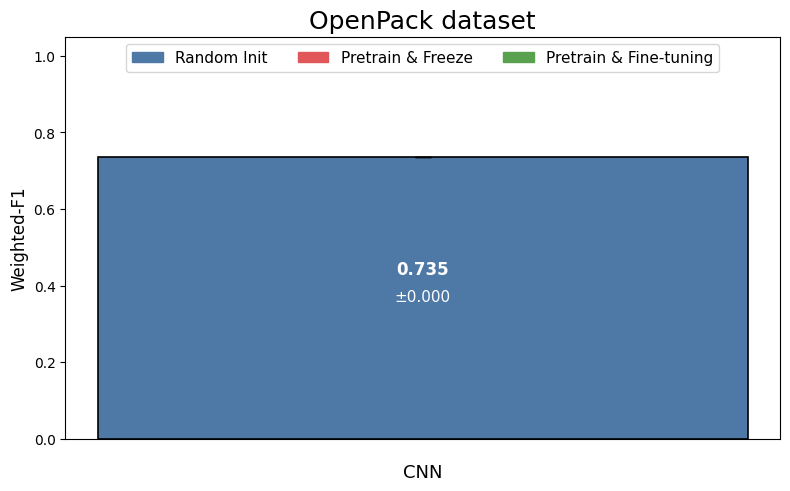

In [200]:
df = pd.DataFrame(
    [(v, s["mean_f1"], s["std_f1"], s["num_seeds"]) for v, s in summary.items()],
    columns=["variant","mean_f1","std_f1","num_seeds"]
)

print("対象 DataFrame:", df["variant"].tolist())

# === 3. T6,8,10 と T1,3,5 を分割せずまとめて 3+3 で gap配置して plot ===
colors5 = [
    "#4e79a7",  # 0
    "#f28e2c",  # 1（使わない）
    "#e15759",  # 2
    "#76b7b2",  # 3（使わない）
    "#59a14f",  # 4
]

strategy_idx_map = {
    "T6_noPT_uniform":     0,
    "T8_PT_frozen":        2,
    "T10_PT_ft_layerwise": 4,
    "T1_noPT_uniform":     0,
    "T3_PT_frozen":        2,
    "T5_PT_ft_layerwise":  4,
}

ordered = [
    "T6_noPT_uniform",
    "T8_PT_frozen",
    "T10_PT_ft_layerwise",
    "T1_noPT_uniform",
    "T3_PT_frozen",
    "T5_PT_ft_layerwise",
]

# df から extract
df_p = df[df["variant"].isin(ordered)].copy()
print("対象に残ったvariant:", df_p["variant"].tolist())  # 6個出ればOK

df_p["order"] = df_p["variant"].apply(lambda v: ordered.index(v))
df_p = df_p.sort_values("order").reset_index(drop=True)

# x 座標 3本 + gap + 3本（分割なし）
x = []
gap = 1.0
pos = 0.0
for i in range(len(df_p)):
    if i == 3:
        pos += gap
    x.append(pos)
    pos += 0.9
x = np.array(x)

# bar colors mapping
bar_colors = [colors5[strategy_idx_map[v]] for v in df_p["variant"].tolist()]

plt.figure(figsize=(8,5))
plt.bar(
    x,
    df_p["mean_f1"].to_numpy(),
    yerr=df_p["std_f1"].to_numpy(),
    color=bar_colors,
    capsize=6,
    edgecolor="black",
    linewidth=1.2,
)

# バー内部 text（mean ± std）
for xi, mw, sw in zip(x, df_p["mean_f1"], df_p["std_f1"]):
    if mw is None: continue
    plt.text(xi, mw*0.6, f"{mw:.3f}", ha="center", va="center",
             fontsize=12, fontweight="bold", color="white")
    plt.text(xi, mw*0.6 - 0.07, f"±{sw:.3f}", ha="center", va="center",
             fontsize=11, color="white")

plt.xticks([],[])
#plt.xticks(x, ordered, fontsize=12, rotation=18)

# 3+3グループの中央ラベル
mid1 = np.mean(x[:3])
mid2 = np.mean(x[3:6])
plt.text(mid1, -0.1, "CNN", ha="center", fontsize=13)
plt.text(mid2, -0.1, "CNN-Transformer", ha="center", fontsize=13)
plt.ylabel("Weighted-F1", fontsize=12)
plt.ylim(0,1.05)

# 凡例（表示戦略3つのみ）
handles = [plt.Rectangle((0,0),1,1,color=c) for c in [colors5[i] for i in [0,2,4]]]
plt.legend(handles, ["Random Init","Pretrain & Freeze","Pretrain & Fine-tuning"],
           ncol=3, fontsize=11, loc="upper center")

plt.title("OpenPack dataset", fontsize=18)
plt.tight_layout()
plt.show()

{'S0100': 0.8282921952305509}


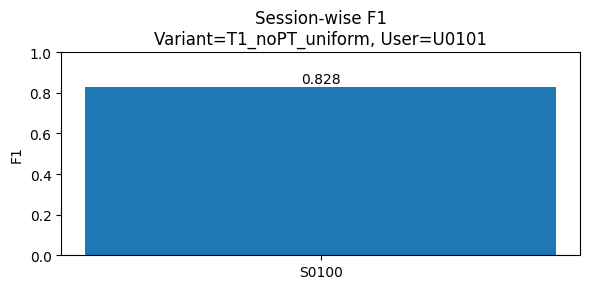

In [201]:
import os
import json
from sklearn.metrics import f1_score

def load_and_compute_f1(base_dir, variant, user, seed=0):
    """
    base_dir: results_loso
    variant : "T1_noPT_uniform"
    user    : "U0101"
    seed    : 0
    """

    target_dir = f"{base_dir}/seed{seed}/{variant}"
    session_f1 = {}

    for sess in sorted(os.listdir(target_dir)):
        sess_dir = os.path.join(target_dir, sess)
        json_path = os.path.join(sess_dir, f"{user}.json")

        if not os.path.isfile(json_path):
            continue

        # --- JSON 読み込み ---
        with open(json_path, "r") as fp:
            data = json.load(fp)

        y_true = data["y_true"]
        y_pred = data["y_pred"]

        # --- F1 計算（weighted） ---
        f1 = f1_score(y_true, y_pred, average="weighted")
        session_f1[sess] = f1

    return session_f1

import matplotlib.pyplot as plt

def plot_f1_bar_for_user(session_f1, variant, user):
    sessions = list(session_f1.keys())
    f1_values = [session_f1[s] for s in sessions]

    plt.figure(figsize=(6, 3))
    plt.bar(sessions, f1_values)

    plt.title(f"Session-wise F1\nVariant={variant}, User={user}")
    plt.ylabel("F1")
    plt.ylim(0, 1)

    for i, v in enumerate(f1_values):
        plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()

variant = "T1_noPT_uniform"
user = "U0101"

session_f1 = load_and_compute_f1(
    base_dir="results_loso",
    variant=variant,
    user=user,
    seed=0
)

print(session_f1)

plot_f1_bar_for_user(session_f1, variant, user)


# Only scenario1

In [202]:
import os, json, numpy as np
from sklearn.metrics import f1_score

def load_variant_scores(root="results_loso"):
    scores = {}  # {variant: [f1_seed0, f1_seed1, ...]}

    for seed in sorted(os.listdir(root)):
        seed_dir = os.path.join(root, seed)
        if not os.path.isdir(seed_dir): 
            continue

        for variant in sorted(os.listdir(seed_dir)):
            var_dir = os.path.join(seed_dir, variant)
            if not os.path.isdir(var_dir):
                continue

            # Score list init
            if variant not in scores:
                scores[variant] = []

            # 各被験者JSONをseed単位で統合してF1を1つ算出
            y_all, p_all = [], []
            for fname in sorted(os.listdir(var_dir)):
                if not fname.endswith(".json"): 
                    continue
                with open(os.path.join(var_dir, fname)) as fp:
                    r = json.load(fp)
                y_all += r["y_true"]
                p_all += r["y_pred"]

            if len(y_all)==0:
                scores[variant].append(None)
            else:
                f1w = f1_score(np.array(y_all), np.array(p_all), average="weighted")
                scores[variant].append(f1w)

    return scores

scores = load_variant_scores()

def summarize_scores(scores):
    summary = {}
    for variant, vals in scores.items():
        vs = [v for v in vals if v is not None]
        summary[variant] = {
            "mean_f1": np.nanmean(vs),
            "var_f1":  np.nanvar(vs),
            "num_seeds": len(vs)
        }
    return summary

summary = summarize_scores(scores)



/tmp/ipykernel_2447983/361361584.py:46: RuntimeWarning: Mean of empty slice
  "mean_f1": np.nanmean(vs),
/tmp/ipykernel_2447983/361361584.py:47: RuntimeWarning: Degrees of freedom <= 0 for slice.
  "var_f1":  np.nanvar(vs),


In [203]:
import os, json, numpy as np
from sklearn.metrics import f1_score

# def load_variant_scores(root="results_loso"):
#     scores = {}  # {variant: [f1_seed0, f1_seed1, ...]}

#     for seed in sorted(os.listdir(root)):
#         seed_dir = os.path.join(root, seed)
#         if not os.path.isdir(seed_dir): 
#             continue

#         for variant in sorted(os.listdir(seed_dir)):
#             var_dir = os.path.join(seed_dir, variant)
#             if not os.path.isdir(var_dir):
#                 continue

#             # Score list init
#             if variant not in scores:
#                 scores[variant] = []

#             # 各被験者JSONをseed単位で統合してF1を1つ算出
#             y_all, p_all = [], []
#             for fname in sorted(os.listdir(var_dir)):
#                 if not fname.endswith(".json"): 
#                     continue
#                 with open(os.path.join(var_dir, fname)) as fp:
#                     r = json.load(fp)
#                 y_all += r["y_true"]
#                 p_all += r["y_pred"]

#             if len(y_all)==0:
#                 scores[variant].append(None)
#             else:
#                 f1w = f1_score(np.array(y_all), np.array(p_all), average="weighted")
#                 scores[variant].append(f1w)

#     return scores

def load_variant_scores_per_subject(root="results_loso"):
    """
    return:
        { variant: [seed0_mean_f1, seed1_mean_f1, ...] }
    """
    scores = {}

    for seed in sorted(os.listdir(root)):
        seed_dir = os.path.join(root, seed)
        if not os.path.isdir(seed_dir):
            continue

        print(f"Loading results from: {seed_dir}")

        for variant in sorted(os.listdir(seed_dir)):
            var_dir = os.path.join(seed_dir, variant)
            if not os.path.isdir(var_dir):
                continue

            # variant の seed 配列を作成
            if variant not in scores:
                scores[variant] = []

            per_subject_f1 = []  # ← ★ ここに被験者ごとのF1を入れる

            # ---- 各JSON（= 各 test subject） ----
            for fname in sorted(os.listdir(var_dir)):
                if not fname.endswith(".json"):
                    continue

                with open(os.path.join(var_dir, fname)) as fp:
                    r = json.load(fp)

                y = np.array(r["y_true"])
                p = np.array(r["y_pred"])

                f1_u = f1_score(y, p, average="weighted")
                #f1_u = f1_score(y, p, average="macro")
                per_subject_f1.append(f1_u)

            # ---- seed のスコアとして「被験者平均」を登録 ----
            if len(per_subject_f1) == 0:
                scores[variant].append(None)
            else:
                mean_f1 = float(np.mean(per_subject_f1))
                scores[variant].append(mean_f1)

    return scores

scores = load_variant_scores_per_subject(root="results_loso")

def summarize_scores(scores):
    summary = {}
    for variant, vals in scores.items():
        vs = [v for v in vals if v is not None]
        summary[variant] = {
            "mean_f1": np.nanmean(vs),
            "std_f1":  np.nanstd(vs),
            "num_seeds": len(vs)
        }
    return summary

summary = summarize_scores(scores)



Loading results from: results_loso/1205
Loading results from: results_loso/1210
Loading results from: results_loso/1212
Loading results from: results_loso/1212_2
Loading results from: results_loso/1212_3
Loading results from: results_loso/seed0


/tmp/ipykernel_2447983/1962643147.py:95: RuntimeWarning: Mean of empty slice
  "mean_f1": np.nanmean(vs),
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [204]:
summary
order = [
    "T6_noPT_uniform",
    "T7_noPT_layerwise",
    "T8_PT_frozen",
    "T9_PT_ft_uniform",
    "T10_PT_ft_layerwise",

    "T6_noPT_uniform_smooth",
    "T7_noPT_layerwise_smooth",
    "T8_PT_frozen_smooth",
    "T9_PT_ft_uniform_smooth",
    "T10_PT_ft_layerwise_smooth",
    
    "T1_noPT_uniform",
    "T2_noPT_layerwise",
    "T3_PT_frozen",
    "T4_PT_ft_uniform",
    "T5_PT_ft_layerwise",
]

summary_ordered = {k: summary[k] for k in order}

KeyError: 'T6_noPT_uniform'

In [ ]:
import pandas as pd
df = pd.DataFrame(
    [(k, v["mean_f1"], v["std_f1"], v["num_seeds"]) for k,v in summary_ordered.items()],
    columns=["variant","mean_f1","std_f1","num_seeds"]
)

md = "| Variant | Mean(F1) | Std(F1) | #Seeds |\n"
md+= "|---|---|---|---|\n"
for _,r in df.iterrows():
    md+= f"| {r.variant} | {r.mean_f1:.3f} | {r.std_f1:.3f} | {int(r.num_seeds)} |\n"
print(md)


# --- df (variant, mean_f1, std_f1, num_seeds) は既にある前提 ---

import matplotlib.pyplot as plt
import numpy as np

# カラーマップ（最大10）
colors10 = [
    "#4e79a7",  # blue
    "#f28e2c",  # orange
    "#76b7b2",  # green-ish
    "#e15759",  # red
    "#59a14f",  # green
    "#af7aa1",  # purple
    "#ff9da7",  # pink
    "#9c755f",  # brown
    "#bab0ac",  # gray
    "#edc948"   # yellow
]


# グループ定義
group_A = ["T6_noPT_uniform","T7_noPT_layerwise","T8_PT_frozen","T9_PT_ft_uniform","T10_PT_ft_layerwise"]
group_B = ["T6_noPT_uniform_smooth","T7_noPT_layerwise_smooth","T8_PT_frozen_smooth","T9_PT_ft_uniform_smooth","T10_PT_ft_layerwise_smooth"]
group_C = ["T1_noPT_uniform","T2_noPT_layerwise","T3_PT_frozen","T4_PT_ft_uniform","T5_PT_ft_layerwise"]

def label_group(v):
    if v in group_A:
        return "A"
    elif v in group_B:
        return "B"
    elif v in group_C:
        return "C"
    else:
        return "Unknown"

df["group"] = df["variant"].apply(label_group)

# A → B → C の順番で concat
df_sorted = pd.concat([
    df[df["group"]=="A"],
    df[df["group"]=="B"],
    df[df["group"]=="C"]
], axis=0).reset_index(drop=True)

import matplotlib.pyplot as plt
import numpy as np

# ====== 色設定：5種類 ======
colors5 = [
    "#4e79a7",  # 1: Random Init + Uniform
    "#f28e2c",  # 2: Random Init + Layerwise
    "#e15759",  # 3: Pretrain + Frozen
    "#76b7b2",  # 4: Pretrain + FT-Uniform
    "#59a14f",  # 5: Pretrain + FT-Layerwise
]

labels5 = [
    "Random Init + Uniform",
    "Random Init + Layerwise",
    "Pretrain + Frozen",
    "Pretrain + Finetune-Uniform",
    "Pretrain + Finetune-Layerwise",
]

# ====== df_sortedから値を取り出す ======
variants = df_sorted["variant"].tolist()
means    = df_sorted["mean_f1"].to_numpy()
stds     = df_sorted["std_f1"].to_numpy()
groups   = df_sorted["group"].tolist()


# ====== x座標：グループ間に隙間 ======
x = []
gap = 2.0   # ← A/B/C 間隔を広く
pos = 0

for i, g in enumerate(groups):
    # グループが変わる瞬間に gap
    if i > 0 and groups[i-1] != g:
        pos += gap
    x.append(pos)
    pos += 0.9  # グループ内は狭め


x = np.array(x)

# ====== グループ内インデックス（0〜4） ======
index_within_group = [(i % 5) for i in range(len(variants))]
bar_colors = [colors5[idx] for idx in index_within_group]


# ====== Plot ======
plt.figure(figsize=(14, 6))

plt.bar(
    x, means, yerr=stds,
    color=bar_colors,
    capsize=6,
    edgecolor="black",
    linewidth=1.3
)


# ====== バー内部に mean と std ======
for xi, m, s in zip(x, means, stds):
    plt.text(xi, m*0.62, f"{m:.3f}",
             ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    plt.text(xi, m*0.62 - 0.05, f"±{s:.3f}",
             ha="center", va="center", fontsize=9, fontweight="bold", color="white")


# ====== x軸ラベルは消す ======
plt.xticks([], [])
plt.ylabel("Weighted F1", fontsize=12)
plt.ylim(0, 1.05)


# ====== グループ中央位置の計算 ======

# A 群
idx_A = np.where(df_sorted["group"]=="A")[0]
mid_A = np.mean(x[idx_A])

# B 群
idx_B = np.where(df_sorted["group"]=="B")[0]
mid_B = np.mean(x[idx_B])

# C 群
idx_C = np.where(df_sorted["group"]=="C")[0]
mid_C = np.mean(x[idx_C])


# ====== グループ名を表示 ======
plt.text(mid_A, -0.14, "CNN-Linear", ha="center", fontsize=13)
plt.text(mid_B, -0.14, "CNN-Linear (Smoothed)", ha="center", fontsize=13)
plt.text(mid_C, -0.14, "MultiCNN-Transformer", ha="center", fontsize=13)


# ====== 凡例 ======
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors5]
plt.legend(handles, labels5, ncol=3, fontsize=11, loc="upper center")

plt.title("OpenPack Ablation(5 seeds): Pretraining × Training Strategy", fontsize=14)
plt.tight_layout()
plt.show()



| Variant | Mean(F1) | Std(F1) | #Seeds |
|---|---|---|---|
| T6_noPT_uniform | nan | nan | 0 |
| T7_noPT_layerwise | nan | nan | 0 |
| T8_PT_frozen | nan | nan | 0 |
| T9_PT_ft_uniform | nan | nan | 0 |
| T10_PT_ft_layerwise | nan | nan | 0 |
| T6_noPT_uniform_smooth | nan | nan | 0 |
| T7_noPT_layerwise_smooth | nan | nan | 0 |
| T8_PT_frozen_smooth | nan | nan | 0 |
| T9_PT_ft_uniform_smooth | nan | nan | 0 |
| T10_PT_ft_layerwise_smooth | nan | nan | 0 |
| T1_noPT_uniform | nan | nan | 0 |
| T2_noPT_layerwise | nan | nan | 0 |
| T3_PT_frozen | nan | nan | 0 |
| T4_PT_ft_uniform | nan | nan | 0 |
| T5_PT_ft_layerwise | nan | nan | 0 |



/tmp/ipykernel_2595082/4125734241.py:157: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and

ValueError: Image size of 146698x570 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1400x600 with 1 Axes>

In [ ]:
!ls results_loso/seed0

T10_PT_ft_layerwise	    T4_PT_ft_uniform	    T7_noPT_layerwise_smooth
T10_PT_ft_layerwise_smooth  T5_PT_ft_layerwise	    T8_PT_frozen
T1_noPT_uniform		    T6_noPT_uniform	    T8_PT_frozen_smooth
T2_noPT_layerwise	    T6_noPT_uniform_smooth  T9_PT_ft_uniform
T3_PT_frozen		    T7_noPT_layerwise	    T9_PT_ft_uniform_smooth


[Warning] Missing dir: results_loso/seed5/T1_noPT_uniform
=== Mean Weighted F1 per seed ===
seed0: nan
seed1: nan
seed2: nan
seed3: nan
seed4: nan


/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


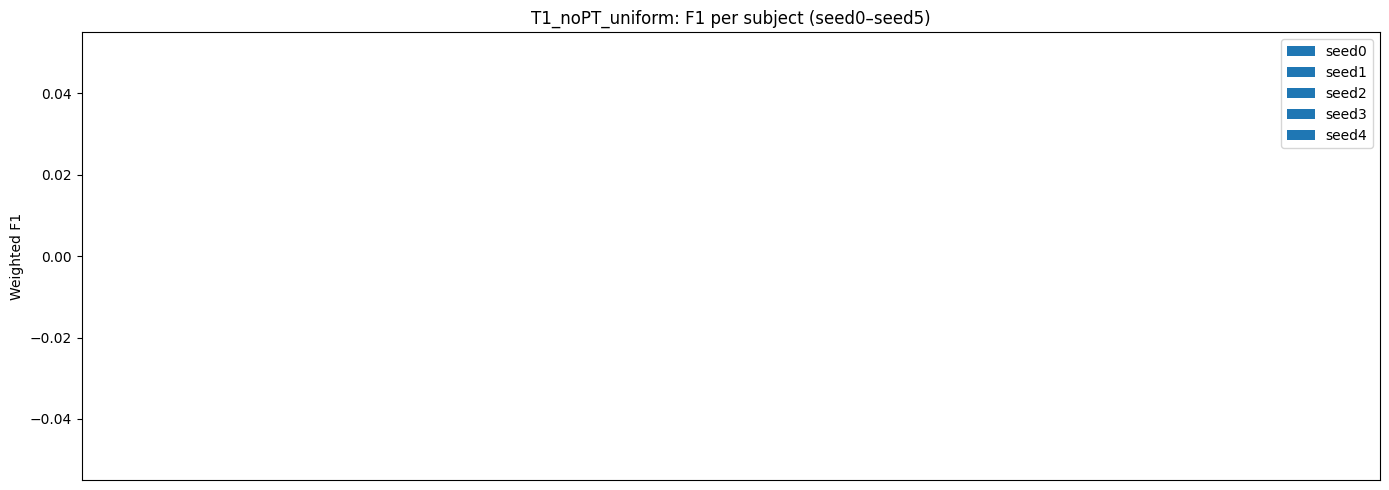

In [ ]:
import os, json, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

def load_subject_f1_for_variant(root, variant, seeds=["seed0","seed1"]):
    """
    return:
        result[seed][subject] = weighted_f1
    """
    result = {}

    for seed in seeds:
        seed_dir = os.path.join(root, seed, variant)
        if not os.path.isdir(seed_dir):
            print(f"[Warning] Missing dir: {seed_dir}")
            continue

        result[seed] = {}

        for fname in sorted(os.listdir(seed_dir)):
            if not fname.endswith(".json"):
                continue

            subject = fname.replace(".json","")
            with open(os.path.join(seed_dir, fname)) as fp:
                r = json.load(fp)

            y = np.array(r["y_true"])
            p = np.array(r["y_pred"])

            f1w = f1_score(y, p, average="weighted")
            result[seed][subject] = f1w

    return result


# ==== 実行 ====
root = "results_loso"
variant = "T1_noPT_uniform"
seeds = [f"seed{i}" for i in range(6)] 

f1_dict = load_subject_f1_for_variant(root, variant, seeds=seeds)


print("=== Mean Weighted F1 per seed ===")
for seed in seeds:
    if seed not in f1_dict:
        continue
    vals = list(f1_dict[seed].values())
    mean_f1 = np.mean(vals)
    print(f"{seed}: {mean_f1:.4f}")


subjects = sorted(list(f1_dict[seeds[0]].keys()))
x = np.arange(len(subjects))
width = 0.12

plt.figure(figsize=(14,5))

for i, seed in enumerate(seeds):
    if seed not in f1_dict:
        continue
    plt.bar(x + width*(i-2.5),
            [f1_dict[seed][s] for s in subjects],
            width=width,
            label=seed)

plt.xticks(x, subjects, rotation=60)
plt.ylabel("Weighted F1")
plt.title(f"{variant}: F1 per subject (seed0–seed5)")
plt.legend()
plt.tight_layout()
plt.show()


[Warning] Missing dir: results_loso/seed5/T2_noPT_layerwise
=== Mean Weighted F1 per seed ===
seed0: nan
seed1: nan
seed2: nan
seed3: nan
seed4: nan


/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


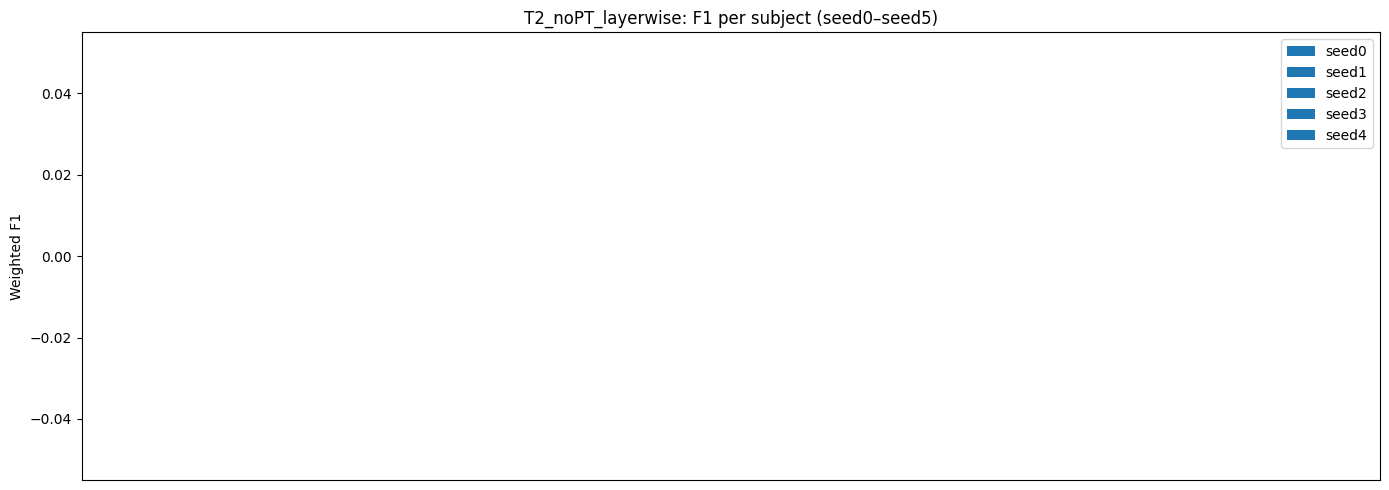

In [ ]:
root = "results_loso"
variant = "T2_noPT_layerwise"
seeds = [f"seed{i}" for i in range(6)] 

f1_dict = load_subject_f1_for_variant(root, variant, seeds=seeds)


print("=== Mean Weighted F1 per seed ===")
for seed in seeds:
    if seed not in f1_dict:
        continue
    vals = list(f1_dict[seed].values())
    mean_f1 = np.mean(vals)
    print(f"{seed}: {mean_f1:.4f}")


subjects = sorted(list(f1_dict[seeds[0]].keys()))
x = np.arange(len(subjects))
width = 0.12

plt.figure(figsize=(14,5))

for i, seed in enumerate(seeds):
    if seed not in f1_dict:
        continue
    plt.bar(x + width*(i-2.5),
            [f1_dict[seed][s] for s in subjects],
            width=width,
            label=seed)

plt.xticks(x, subjects, rotation=60)
plt.ylabel("Weighted F1")
plt.title(f"{variant}: F1 per subject (seed0–seed5)")
plt.legend()
plt.tight_layout()
plt.show()


[Warning] Missing dir: results_loso/seed5/T2_noPT_layerwise
=== Mean Weighted F1 per seed ===
seed0: nan
seed1: nan
seed2: nan
seed3: nan
seed4: nan


/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


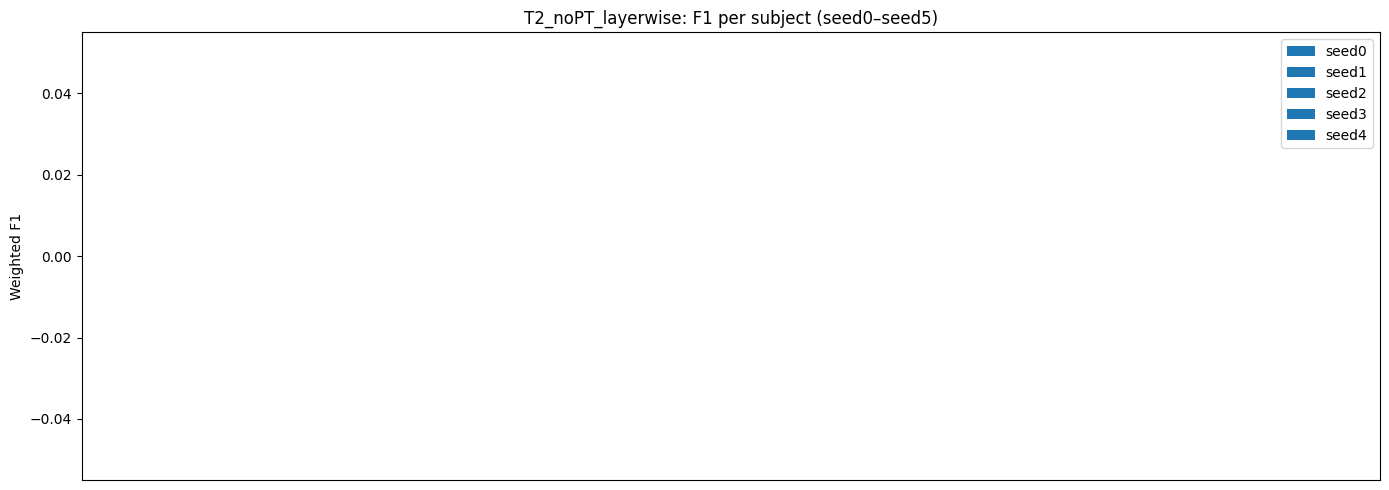

In [ ]:
root = "results_loso"
variant = "T2_noPT_layerwise"
seeds = [f"seed{i}" for i in range(6)] 

f1_dict = load_subject_f1_for_variant(root, variant, seeds=seeds)


print("=== Mean Weighted F1 per seed ===")
for seed in seeds:
    if seed not in f1_dict:
        continue
    vals = list(f1_dict[seed].values())
    mean_f1 = np.mean(vals)
    print(f"{seed}: {mean_f1:.4f}")


subjects = sorted(list(f1_dict[seeds[0]].keys()))
x = np.arange(len(subjects))
width = 0.12

plt.figure(figsize=(14,5))

for i, seed in enumerate(seeds):
    if seed not in f1_dict:
        continue
    plt.bar(x + width*(i-2.5),
            [f1_dict[seed][s] for s in subjects],
            width=width,
            label=seed)

plt.xticks(x, subjects, rotation=60)
plt.ylabel("Weighted F1")
plt.title(f"{variant}: F1 per subject (seed0–seed5)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
def detect_num_classes(scores, root="results_loso", target_session="S0100"):
    """
    各 variant の JSON を1つ読み，中の y_true のユニーク数から
    『何クラス分類だったか』を推定して表示する
    """
    print("\n===== Class Count Per Variant =====")

    for variant in scores.keys():
        # seed0 を優先して検索（存在すれば）
        seed_dirs = sorted(os.listdir(root))
        json_found = False
        y_unique = None

        for seed in seed_dirs:
            seed_dir = os.path.join(root, seed)
            var_dir  = os.path.join(seed_dir, variant)
            sess_dir = os.path.join(var_dir, target_session)

            if not os.path.isdir(sess_dir):
                continue

            # どれか1つ JSON を読む
            for fname in sorted(os.listdir(sess_dir)):
                if fname.endswith(".json"):
                    json_path = os.path.join(sess_dir, fname)
                    with open(json_path, "r") as fp:
                        r = json.load(fp)
                    y = np.array(r["y_true"])
                    y_unique = np.unique(y)
                    json_found = True
                    break

            if json_found:
                break

        # 出力
        if not json_found:
            print(f"{variant}: JSON not found")
        else:
            print(f"{variant}: {len(y_unique)} classes → {y_unique}")

detect_num_classes(scores)


===== Class Count Per Variant =====
T10_PT_ft_layerwise: 11 classes → [ 0  1  2  3  4  5  6  7  8  9 10]
T1_noPT_uniform: 11 classes → [ 0  1  2  3  4  5  6  7  8  9 10]
T3_PT_frozen: 11 classes → [ 0  1  2  3  4  5  6  7  8  9 10]
T5_PT_ft_layerwise: 11 classes → [ 0  1  2  3  4  5  6  7  8  9 10]
T6_noPT_uniform: 11 classes → [ 0  1  2  3  4  5  6  7  8  9 10]
T8_PT_frozen: 11 classes → [ 0  1  2  3  4  5  6  7  8  9 10]
